In [16]:
# can be used by strict and semi isomorphism checks too!!!

def backtrack(Q1, Q2, f, seen, check):
    
    if len(f) == len(Q1): # potential solution works! never includes final pair so add to f
        leftover1 = [q for q in Q1 if q not in f]
        leftover2 = [q for q in Q2 if q not in f.values()]
        f[leftover1[0]] = leftover2[0]
        return True

    q1 = Q1[len(f)] # get next value in Q1

    for q2 in Q2:
        f[q1] = q2 # get mapping of Q2 from Q1
        
        if check(f): # check the extention to the next state
            seen.add(q2)

            if backtrack(Q1, Q2, f, seen, check): # move to next state
                return True
                
            seen.remove(q2) # potential solution failed! retreat
        f.pop(q1)
    return False

In [17]:
from itertools import permutations

def is_weak_isomorphic(A1, A2):
    
    def weak_check(f): # check if t2(f(q),g(a)) == f(t1(q,a)) 
        for q1, q2 in f.items():
            for a1 in S1:
                a2 = g[a1]
                q1_next = t1[(q1,a1)]
                if q1_next in f:
                    q2_next = t2[(q2,a2)]
                    if f[q1_next] != q2_next:
                        return False
        return True

    Q1, S1, t1, qs1, F1 = A1
    Q2, S2, t2, qs2, F2 = A2
    
    S1 = list(S1) # annoyed i cant set variables as lists in the lines above
    S2 = list(S2)
    F1 = list(F1)
    F2 = list(F2)

    if len(Q1) != len(Q2) or len(S1) != len(S2) or len(F1) != len(F2):
        return False, None, None

    for trial in permutations(S2): # trying different orders of S2 until one permutation matches
        g = dict(zip(S1, trial)) # set g = {S1 : trial}
        f = {qs1: qs2} # assuming f(qs1) == qs2 !!
        seen = {qs2}

        # since we have already used qs1 and qs2, we can remove them from Q1 and Q2
        Q1n = [q for q in Q1 if q != qs1]
        Q2n = [q for q in Q2 if q != qs2]
        
        # backtrack search to see if f and g are solutions
        if backtrack(Q1n, Q2n, f, seen, weak_check):
            for end1 in F1: # checking f(F1) == F2
                if f[end1] not in F2:
                    return False, None, None
            return True, f, g

    return False, None, None

In [18]:
A1 = (
    {0,1,2,3,4},
    {0,1},
    {   (0,0):1, (0,1):4,
        (1,0):0, (1,1):3,
        (2,0):3, (2,1):0,
        (3,0):2, (3,1):1,
        (4,0):1, (4,1):2},
    2,
    {3,2})

A2 = (
    {4,5,6,7,8},
    {2,3},
    {   (4,3):5, (4,2):8,
        (5,3):4, (5,2):7,
        (6,3):7, (6,2):4,
        (7,3):6, (7,2):5,
        (8,3):5, (8,2):6},
    5, 
    {7,6})

is_weak_isomorphic(A1, A2)

(False, None, None)

DFAs are not weak isomorphic!


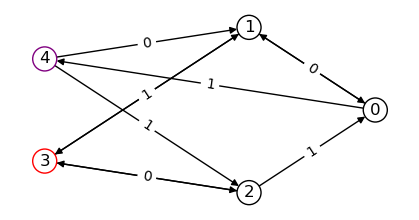

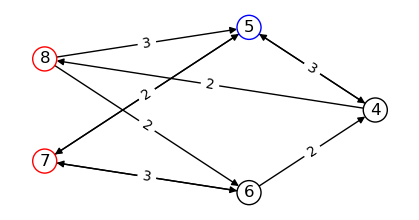

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

def colours_edges(Q, qs, F):
    edge_colours = ["k"]*len(Q)
    for i, node in enumerate(Q):
        if node == qs:
            edge_colours[i] = "b"
        elif node in F:
            edge_colours[i] = "r"
        if node == qs and node in F:
            edge_colours[i] = "purple"
    return edge_colours

def visualise_DFA(A):
    
    Q, S, t, qs, F = A

    edge_colours = colours_edges(Q, qs, F)

    G = nx.MultiDiGraph()
    for (fromm, alpha), to in t.items():
            G.add_edge(fromm, to, label = alpha)

    pos = nx.circular_layout(G)
    plt.figure(figsize = (4,2))
    nx.draw(G, pos, with_labels = True, node_color = "w", edgecolors = edge_colours)
    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data = True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels)
    plt.show()

def visualise(A1, A2, iso_type):
    if iso_type == "strict":
        result, f = is_strict_isomorphic(A1, A2)
    elif iso_type == "weak" or iso_type == "semi":
        result, f, g  = is_weak_isomorphic(A1, A2)
    
    if not result:
        print(f"DFAs are not {iso_type} isomorphic!")
    
    else:
        if iso_type == "strict":
            print(f"f = {f}")
        else:
            print(f"f = {f}, g = {g}")
            
    visualise_DFA(A1)
    visualise_DFA(A2)

visualise(A1, A2, "weak")

In [24]:
from IPython.display import display
from ipywidgets import IntSlider, interactive_output, fixed

def interact_backtrack_widgets(G1, frames1, G2, frames2, edge_colours1, edge_colours2):
    i_slider = IntSlider(value = 0, min = 0, max = len(frames1)-1, description = "Step")
    graph1 = interactive_output(draw_colouring_from_frames, {'i': i_slider, 'G': fixed(G1), 'frames': fixed(frames1), 'edge_colours': fixed(edge_colours1)})
    graph2 = interactive_output(draw_colouring_from_frames, {'i': i_slider, 'G': fixed(G2), 'frames': fixed(frames2), 'edge_colours': fixed(edge_colours2)})
    return i_slider, graph1, graph2


def draw_colouring_from_frames(G, frames, i, edge_colours):
    pos = nx.circular_layout(G)
    plt.figure(figsize = (5,2))
    colours, edge = frames[i]

    nx.draw_networkx(G, pos, node_color = colours, edgecolors = edge_colours, with_labels = True)
    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data = True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels)
    
    if edge:
        nx.draw_networkx_edges(G, pos, edgelist = [edge], edge_color = "r", width = 3)


def colouring_frames(G, Q, S, t):
    colours = ["w"] * len(Q)
    frames = []
    for i in range(len(Q)):
        colours[i] = "lightcoral"
        frames.append((colours.copy(), None))
        for s in S:
            next_state = t[Q[i], s]
            place = Q.index(next_state)
            colours[place] = "lightcoral"
            frames.append((colours.copy(), (Q[i], Q[place])))
            colours[place] = "w"
        colours[i] = "w"
    return frames


Q1, S1, t1, qs1, F1 = A1
Q2, S2, t2, qs2, F2 = A2

Q1 = list(Q1)
Q2 = list(Q2)

edge_colours1 = colours_edges(Q1, qs1, F1)
edge_colours2 = colours_edges(Q2, qs2, F2)

G1 = nx.MultiDiGraph()
G1.add_nodes_from(Q1)
for (fromm, alpha), to in t1.items():
    G1.add_edge(fromm, to, label = alpha)


G2 = nx.MultiDiGraph()
G2.add_nodes_from(Q2)
for (fromm, alpha), to in t2.items():
    G2.add_edge(fromm, to, label = alpha)

frames1 = colouring_frames(G1, Q1, S1, t1)
frames2 = colouring_frames(G2, Q2, S2, t2)
i_slider, graph1, graph2 = interact_backtrack_widgets(G1, frames1, G2, frames2, edge_colours1, edge_colours2)

display(i_slider)
display(graph1)
display(graph2)

IntSlider(value=0, description='Step', max=14)

Output()

Output()